# Setup

In [135]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [136]:
import logging
import sys
sys.path.append("../")

from utils.seed_all import seed_all
from metrics.factory import MetricsFactory

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('sequence_log')
logger.setLevel(logging.INFO)

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

In [137]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

In [138]:
import os

import yaml


def get_window_metrics(base_path):
    windows = {}

    runs = [f for f in os.listdir(base_path)]
    for run in runs:
        run_path = f'{base_path}/{run}'
        print(run_path)

        if not os.path.exists(f'{run_path}/train_labels_predictions.pt'):
            continue

        try:
            with open(f'{run_path}/config.yaml', "r") as f:
                config = yaml.safe_load(f)
            path = f'{run_path}/train_labels_predictions.pt'
            cache = torch.load(path, weights_only=False)
            y_true, y_out = cache['y_true'], cache['y_scores']
            y_pred, y_scores = y_out
            y_pred = np.array(y_pred)
            y_scores = np.array(y_scores)
            y_true['scores'] = y_scores.mean(axis=(1, 2))

            y_true_benign = y_true[y_true["label"] == 'Normal']
            mean = y_true_benign["scores"].mean()
            std = y_true_benign["scores"].std()
            windows[config['pre_processing']['window_size']] = {'mean': mean, 'std': std}
        except:
            continue

    return windows

In [146]:
def density_function(y_true_benign, quantile=0.9999):
    threshold = y_true_benign["scores"].quantile(quantile)

    # Calculate mean and std
    mean = y_true_benign["scores"].mean()
    std = y_true_benign["scores"].std()

    # Plot histogram + KDE
    # y_true_benign["scores"].plot(kind="hist", bins=20, density=True, alpha=0.6, edgecolor="black")
    y_true_benign["scores"].plot(kind="kde")

    # Add mean line
    plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")

    # Add ±1 std lines
    plt.axvline(mean - std, color="blue", linestyle=":", linewidth=2, label=f"-1 Std = {mean-std:.2f}")
    plt.axvline(mean + std, color="blue", linestyle=":", linewidth=2, label=f"+1 Std = {mean+std:.2f}")
    plt.axvline(threshold, color="yellow", linestyle=":", linewidth=2, label=f"Quantile={quantile}")

    plt.xlabel("Scores")
    plt.title("Scores Distribution with Mean & Std")
    plt.legend()
    plt.show()

In [139]:
# w_metrics = get_window_metrics('../runs/ALL_w_size_tunning')
# w_metrics

# Prediction

In [140]:
import yaml


base_file = '../runs/base_config/ALL_tcn_pred_TOWIDS_20250917_122946'
with open(f'{base_file}/config.yaml', "r") as f:
    config = yaml.safe_load(f)
path = f'{base_file}/train_labels_predictions.pt'
cache = torch.load(path, weights_only=False)
y_true, y_out = cache['y_true'], cache['y_scores']
y_pred, y_scores = y_out
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)
y_true['scores'] = y_scores.mean(axis=(1, 2))

In [141]:
y_true_benign = y_true[y_true["label"] == 'Normal']
mean = y_true_benign["scores"].mean()
std = y_true_benign["scores"].std()

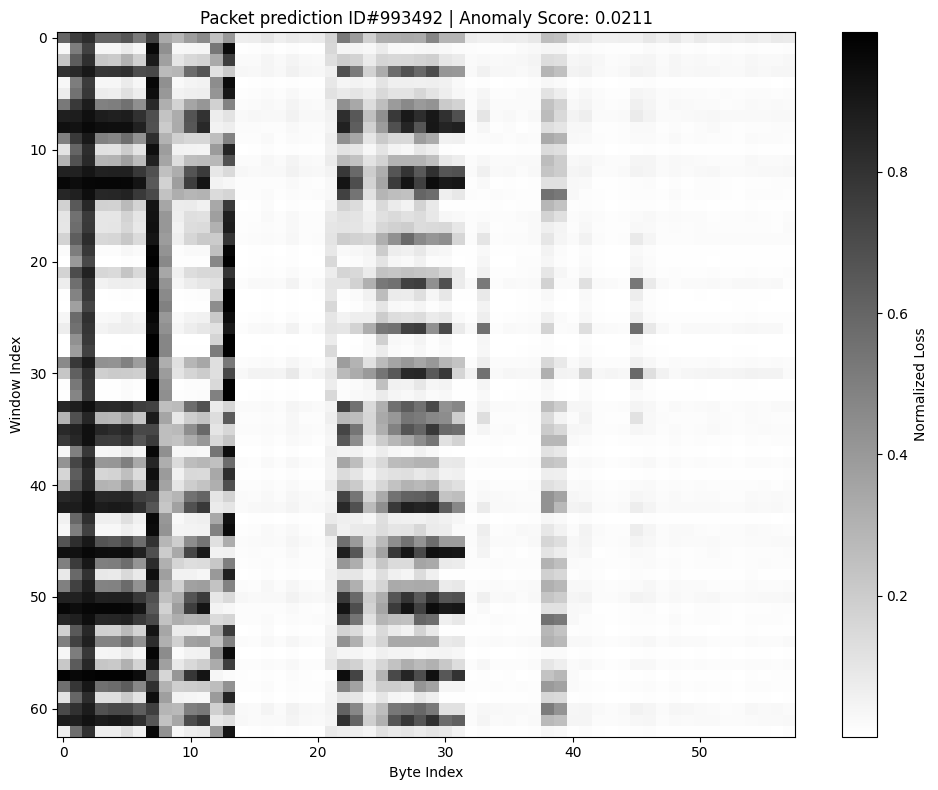

In [134]:
idx = y_true_benign.index[2]
plot_img_loss(y_pred[idx], name=f'Packet prediction ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

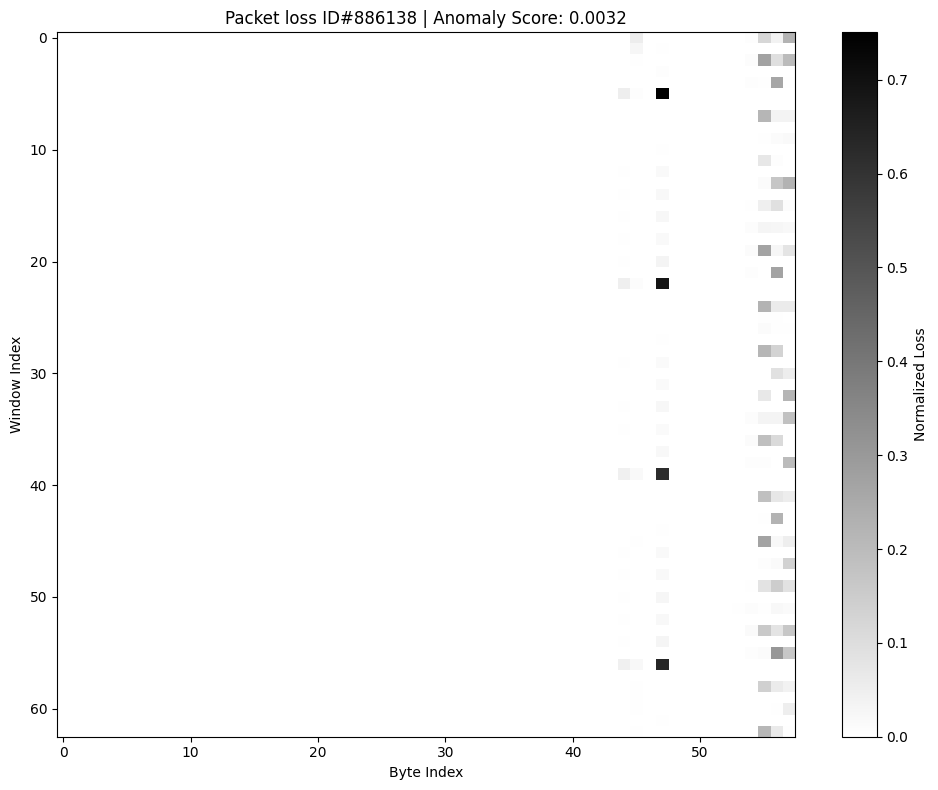

In [126]:
idx = y_true_benign.index[2]
plot_img_loss(y_scores[idx], name=f'Packet loss ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

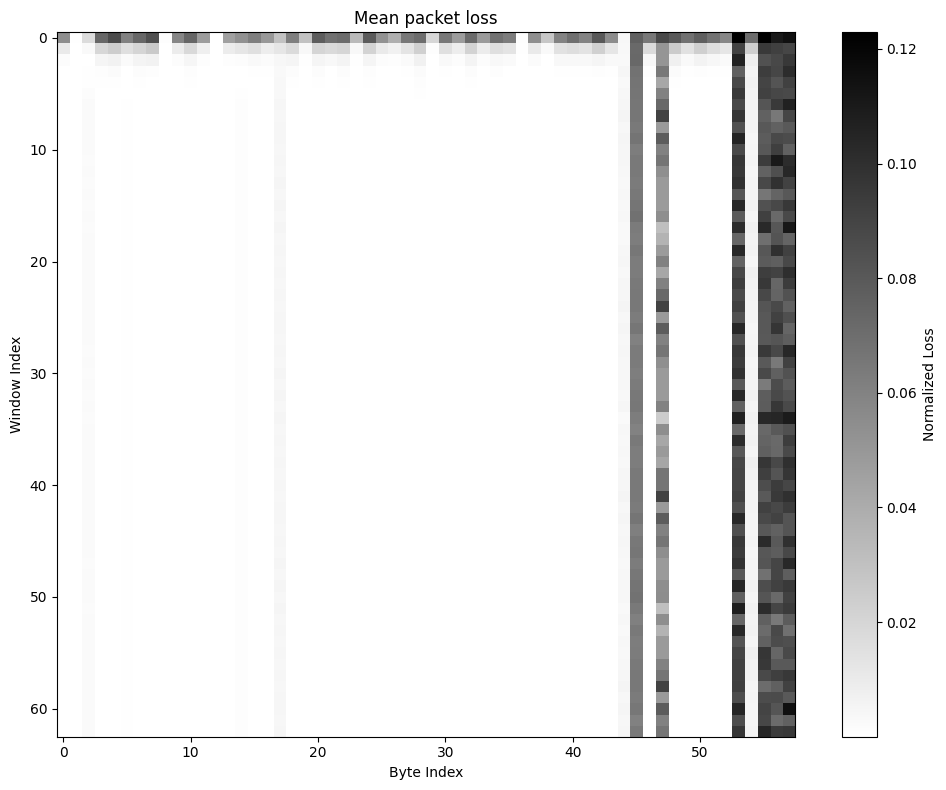

In [118]:
plot_img_loss(y_scores[y_true['label'] == 'Normal'].mean(0), name=f'Mean packet loss')

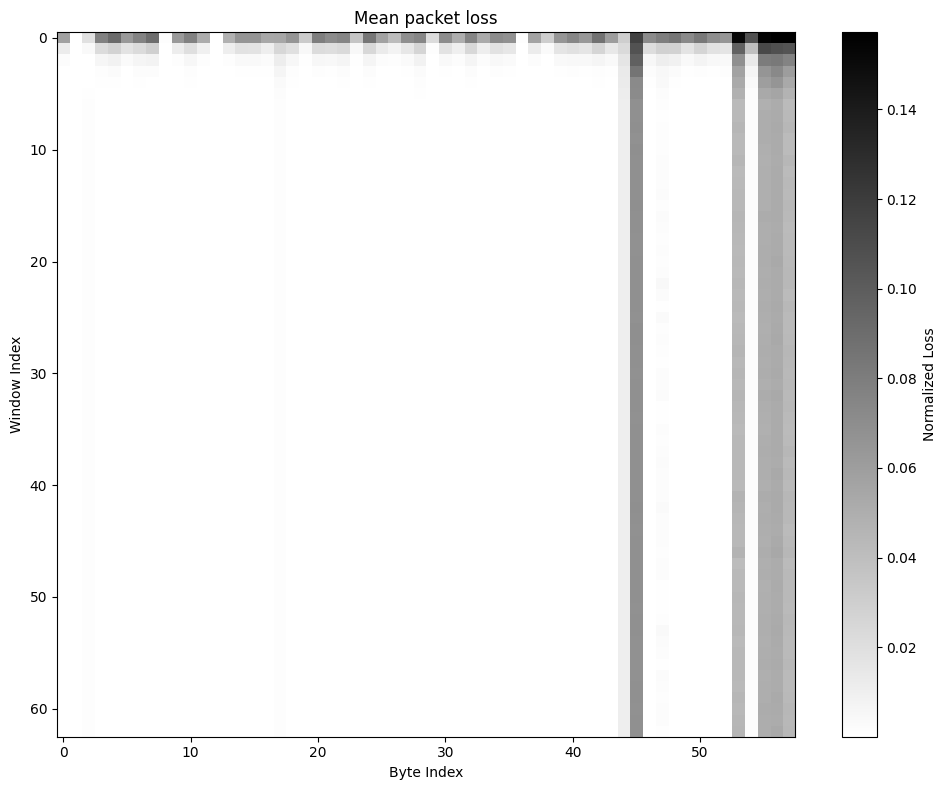

In [114]:
plot_img_loss(y_scores[y_true['label'] != 'Normal'].mean(0), name=f'Mean packet loss')

In [142]:
def get_threshold_table(y_true_benign):
    ts = [0.95, 0.98, 0.99, 0.999, 0.9999]
    r = {}
    for t in ts:
        threshold = y_true_benign["scores"].quantile(t)
        fp = y_true_benign[y_true_benign["scores"] > threshold]
        r[t] = {
            'count': len(fp),
            'mean': fp['scores'].mean(),
            'std': fp['scores'].std(),
            # 'fp': fp
        }
    return r

In [143]:
t_results = get_threshold_table(y_true_benign)

In [144]:
pd.DataFrame(t_results)

,0.9500,0.9800,0.9900,0.9990,0.9999
count,550.000000,220.000000,110.000000,11.000000,2.000000
mean,0.033010,0.035006,0.036596,0.041645,0.043145
std,0.002216,0.002251,0.002214,0.000936,0.001060


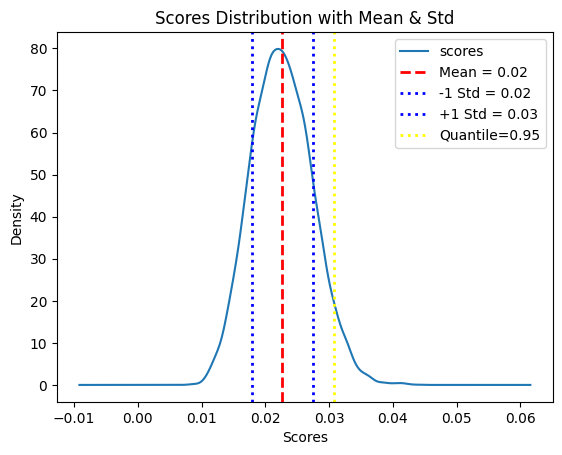

In [156]:
q = 0.95
density_function(y_true_benign, quantile=q)

In [157]:
metrics_handler = MetricsFactory().get({'metrics': {'name': 'anomaly_detector', 'quantile': q }}, logger)
metrics = metrics_handler.get_overall_metrics(y_true, (y_pred, y_scores))

2025-09-18 18:33:45,082 | INFO | Metrics 
{
    "AUCROC": 0.9158585145147037,
    "Accuracy": 0.8057655562017114,
    "TPR": 0.6844359464627151,
    "FPR": 0.050004545867806165,
    "Precision": 0.9420991683335088,
    "F1-score": 0.7928590413750333,
    "optimal_threshold": 0.030776288546621802,
    "mean": 0.022640269249677658,
    "std": 0.0047765616327524185,
    "tpr_per_attack": {
        "PTP Sync": 0.999735519703782,
        "CAN DoS": 0.47058823529411764,
        "Switch MAC Flooding": 0.9990521327014218,
        "CAN Replay": 0.5551181102362205,
        "Frame Injection": 0.1495754408883083
    },
    "aucroc_per_attack": {
        "Switch MAC Flooding": 0.9998448372514691,
        "Frame Injection": 0.6422424008738044,
        "PTP Sync": 0.9999353407112892,
        "CAN DoS": 0.8950498349389248,
        "CAN Replay": 0.9154396552156139
    }
}
